In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')


print(train.shape)
print(test.shape)

display(train.head(10))
display(test.head(10))


(6999, 11)
(4000, 10)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
ID,,,,,,,,,,,
1,C,Ship,2.0,2,135,3.0,low,M,NaN,1339,1
2,F,Flight,5.0,3,225,5.0,low,F,6.0,1082,0
3,F,Ship,3.0,1,229,3.0,low,M,NaN,4971,1
4,F,Ship,3.0,2,228,NaN,medium,M,2.0,5640,0
5,D,Flight,NaN,1,195,6.0,high,F,NaN,4944,1
6,B,Ship,4.0,5,171,3.0,low,F,NaN,1683,1
7,A,Ship,6.0,3,282,4.0,low,M,9.0,1417,1
8,F,Flight,5.0,2,161,3.0,low,M,NaN,5804,1
9,F,Ship,NaN,1,274,4.0,low,M,3.0,5979,0


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms
ID,,,,,,,,,,
7000,F,Ship,3.0,1,274,NaN,high,M,NaN,4352
7001,F,Ship,3.0,4,136,2.0,medium,F,NaN,1056
7002,A,Flight,NaN,5,140,3.0,low,F,7.0,5383
7003,C,Ship,NaN,1,291,4.0,low,F,NaN,1880
7004,F,?,4.0,2,147,3.0,low,F,5.0,5174
7005,D,Ship,NaN,1,221,NaN,low,F,64.0,?
7006,F,Ship,NaN,4,253,3.0,medium,F,4.0,5236
7007,D,Road,6.0,3,244,4.0,low,F,NaN,1317
7008,F,Ship,NaN,5,150,2.0,low,M,29.0,1934


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ======== 결측치 ===========

# 결측여부 컬럼 추가
train['Discount_missing'] = train['Discount_offered'].isnull().astype(int)
test['Discount_missing'] = test['Discount_offered'].isnull().astype(int)

median_value = train['Discount_offered'].median()

train['Discount_offered'] = train['Discount_offered'].fillna(median_value)
test['Discount_offered'] = test['Discount_offered'].fillna(median_value)

# 문의 횟수
call_median = train['Customer_care_calls'].median()

train['Customer_care_calls'] = train['Customer_care_calls'].fillna(call_median)
test['Customer_care_calls'] = test['Customer_care_calls'].fillna(call_median)

print(train['Customer_care_calls'].isnull().sum())


# 이전 구매 횟수
prior_median = train['Prior_purchases'].median()

train['Prior_purchases'] = train['Prior_purchases'].fillna(prior_median)
test['Prior_purchases'] = test['Prior_purchases'].fillna(prior_median)

print(train['Prior_purchases'].isnull().sum())


print(train.isnull().sum().sum())
print(test.isnull().sum().sum())


# ========= 오타 제거 ==========

# ==== 컬럼 공백 제거
train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

# ==== Mode_of Shipment
def clean_mode(x):
    x = x.strip() # 앞뒤 공백 제거
    x = x.replace('zk', '') # zk 제거
    if x == '?':
        return 'Ship' # 가장 많은 값인 Ship으로 대체
    return x

# Train과 Test 모두 적용
train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

# 2. 이제 깔끔하게 ['Ship', 'Flight', 'Road']만
print(train['Mode_of_Shipment'].unique())
print(test['Mode_of_Shipment'].unique())


# ==== Product_importance
train['Product_importance'].unique()
# array(['low', 'medium', 'high', '?', 'mediumm', 'loww', 'highh']
train['Product_importance'].value_counts()
# low        3344
# medium     2982
# high        573
# ?            97
# mediumm       1
# loww          1
# highh         1

# 1. 오타 먼저 수정
replace_dict = {
    'loww': 'low',
    'mediumm': 'medium',
    'highh': 'high'
}

train['Product_importance'] = train['Product_importance'].replace(replace_dict)
test['Product_importance'] = test['Product_importance'].replace(replace_dict)

# 2. mode 계산 (오타 정리 후!)
mode_val = train['Product_importance'].mode()[0]

# 3. '?' → mode
train['Product_importance'] = train['Product_importance'].replace('?', mode_val)
test['Product_importance'] = test['Product_importance'].replace('?', mode_val)

print(train['Product_importance'].unique())
print(test['Product_importance'].unique())     # array(['high', 'medium', 'low']

# ===== Weight_in_gms

import numpy as np

# train
train['Weight_in_gms'] = train['Weight_in_gms'].replace('?', np.nan)
train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')

# test
test['Weight_in_gms'] = test['Weight_in_gms'].replace('?', np.nan)
test['Weight_in_gms'] = pd.to_numeric(test['Weight_in_gms'], errors='coerce')

median_weight = train['Weight_in_gms'].median()

train['Weight_in_gms'] = train['Weight_in_gms'].fillna(median_weight)
test['Weight_in_gms'] = test['Weight_in_gms'].fillna(median_weight)

0
0
0
0
['Ship' 'Flight' 'Road']
['Ship' 'Flight' 'Road']
['low' 'medium' 'high']
['high' 'medium' 'low']


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6999 entries, 1 to 6999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_block      6999 non-null   object 
 1   Mode_of_Shipment     6999 non-null   object 
 2   Customer_care_calls  6999 non-null   float64
 3   Customer_rating      6999 non-null   int64  
 4   Cost_of_the_Product  6999 non-null   int64  
 5   Prior_purchases      6999 non-null   float64
 6   Product_importance   6999 non-null   object 
 7   Gender               6999 non-null   object 
 8   Discount_offered     6999 non-null   float64
 9   Weight_in_gms        6999 non-null   float64
 10  Reached.on.Time_Y.N  6999 non-null   int64  
 11  Discount_missing     6999 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 710.8+ KB


In [71]:
train['Warehouse_block '].unique()      # ['C', 'F', 'D', 'B', 'A']
train['Mode_of_Shipment'].unique()
train['Mode_of_Shipment'].value_counts()
test['Mode_of_Shipment'].value_counts()

Mode_of_Shipment
 Ship      2551
 Flight     631
 Road       595
?           221
 Shipzk       1
 Roadzk       1
Name: count, dtype: int64

In [72]:
# 수정
def clean_mode(x):
    x = x.strip() # 앞뒤 공백 제거
    x = x.replace('zk', '') # zk 제거
    if x == '?':
        return 'Ship' # 가장 많은 값인 Ship으로 대체
    return x

# Train과 Test 모두 적용
train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

# 2. 이제 깔끔하게 ['Ship', 'Flight', 'Road']만 남을 거야.
print(train['Mode_of_Shipment'].unique())
print(test['Mode_of_Shipment'].unique())

['Ship' 'Flight' 'Road']
['Ship' 'Flight' 'Road']


In [73]:
train['Product_importance'].unique()
# array(['low', 'medium', 'high', '?', 'mediumm', 'loww', 'highh']
train['Product_importance'].value_counts()
# low        3344
# medium     2982
# high        573
# ?            97
# mediumm       1
# loww          1
# highh         1

# 수정
# train 기준 정리
train['Product_importance'] = train['Product_importance'].replace({
    'loww': 'low',
    'mediumm': 'medium',
    'highh': 'high',
    '?': 'low'
})

# test도 동일하게
test['Product_importance'] = test['Product_importance'].replace({
    'loww': 'low',
    'mediumm': 'medium',
    'highh': 'high',
    '?': 'low'
})

print(train['Product_importance'].unique())
print(test['Product_importance'].unique())     # array(['high', 'medium', 'low']

['low' 'medium' 'high']
['high' 'medium' 'low']


In [74]:
train['Gender'].unique()

array(['M', 'F'], dtype=object)

In [75]:
train['Weight_in_gms'].unique()
# 범주화 하는게 어떨까?

array(['1339', '1082', '4971', ..., '4075', '2486', '1480'],
      shape=(3332,), dtype=object)

---

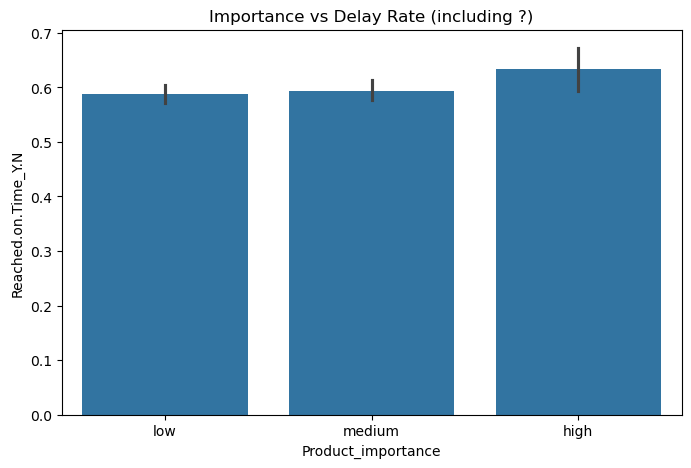

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# '?'를 포함해서 중요도별 지연율 확인
plt.figure(figsize=(8, 5))
sns.barplot(x='Product_importance', y='Reached.on.Time_Y.N', data=train)
plt.title('Importance vs Delay Rate (including ?)')
plt.show()

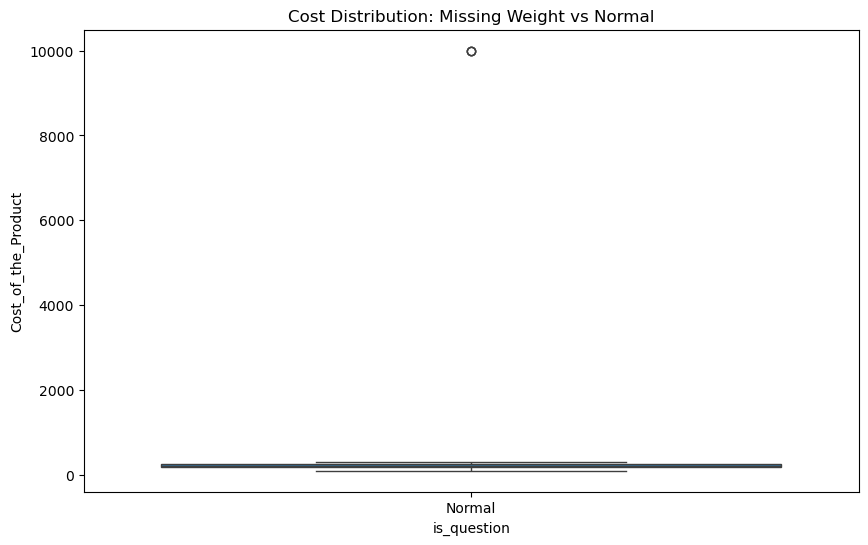

In [30]:
# 무게가 '?'인 데이터와 숫자인 데이터의 가격 분포 비교
# train['weight_is_q'] = train['Weight_in_gms'].apply(lambda x: '?' if x == '?' else 'Number')
# sns.boxplot(x='weight_is_q', y='Cost_of_the_Product', data=train)
# plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 시각화용 카피 데이터 생성
df_viz = train.copy()

# 2. '?' 여부 기록 (변환 전에 해야 함!)
df_viz['is_question'] = df_viz['Weight_in_gms'].apply(lambda x: 'Missing(?)' if x == '?' else 'Normal')

# 3. 숫자형으로 강제 변환 (문자는 NaN이 됨)
df_viz['Weight_numeric'] = pd.to_numeric(df_viz['Weight_in_gms'], errors='coerce')

# 4. 가격 분포 비교 시각화
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_question', y='Cost_of_the_Product', data=df_viz)
plt.title('Cost Distribution: Missing Weight vs Normal')
plt.show()

In [76]:
import numpy as np

# train
train['Weight_in_gms'] = train['Weight_in_gms'].replace('?', np.nan)
train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')

# test
test['Weight_in_gms'] = test['Weight_in_gms'].replace('?', np.nan)
test['Weight_in_gms'] = pd.to_numeric(test['Weight_in_gms'], errors='coerce')

median_weight = train['Weight_in_gms'].median()

train['Weight_in_gms'].fillna(median_weight, inplace=True)
test['Weight_in_gms'].fillna(median_weight, inplace=True)

In [ ]:
train['Weight_in_gms'].

In [77]:
median_weight = train['Weight_in_gms'].median()

train['Weight_in_gms'].fillna(median_weight, inplace=True)
test['Weight_in_gms'].fillna(median_weight, inplace=True)

C:\Users\agnes\AppData\Local\Temp\ipykernel_22072\1211921575.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Weight_in_gms'].fillna(median_weight, inplace=True)
C:\Users\agnes\AppData\Local\Temp\ipykernel_22072\1211921575.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

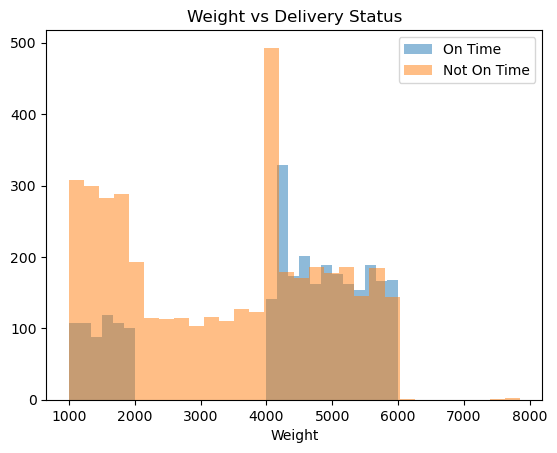

In [78]:
plt.hist(train[train['Reached.on.Time_Y.N'] == 0]['Weight_in_gms'], bins=30, alpha=0.5, label='On Time')
plt.hist(train[train['Reached.on.Time_Y.N'] == 1]['Weight_in_gms'], bins=30, alpha=0.5, label='Not On Time')

plt.legend()
plt.xlabel('Weight')
plt.title('Weight vs Delivery Status')
plt.show()

In [79]:
total = train[(train['Weight_in_gms'] >= 2000) & 
              (train['Weight_in_gms'] <= 4000)].shape[0]

late = train[(train['Weight_in_gms'] >= 2000) & 
             (train['Weight_in_gms'] <= 4000) &
             (train['Reached.on.Time_Y.N'] == 1)].shape[0]

print(late / total)

0.998046875


In [159]:
train['weight_group'] = pd.cut(
    train['Weight_in_gms'],
    bins=[0,1000,2000,3000,4000,10000]
)

test['weight_group'] = pd.cut(
    train['Weight_in_gms'],
    bins=[0,1000,2000,3000,4000,10000]
)

train.groupby('weight_group')['Reached.on.Time_Y.N'].mean()

weight_group
(0, 1000]             NaN
(1000, 2000]     0.671704
(2000, 3000]     1.000000
(3000, 4000]     1.000000
(4000, 10000]    0.456404
Name: Reached.on.Time_Y.N, dtype: float64

In [153]:
train['weight_group'].count

<bound method Series.count of ID
1        (1000, 2000]
2        (1000, 2000]
3       (4000, 10000]
4       (4000, 10000]
5       (4000, 10000]
            ...      
6995     (1000, 2000]
6996    (4000, 10000]
6997     (1000, 2000]
6998    (4000, 10000]
6999    (4000, 10000]
Name: weight_group, Length: 6999, dtype: category
Categories (5, interval[int64, right]): [(0, 1000] < (1000, 2000] < (2000, 3000] < (3000, 4000] < (4000, 10000]]>

In [81]:
train['weight_group'].value_counts()

weight_group
(4000, 5000]    2303
(1000, 2000]    1919
(3000, 4000]     514
(2000, 3000]     506
(0, 1000]          0
Name: count, dtype: int64

In [82]:
pd.crosstab(train['Mode_of_Shipment'],
            train['Reached.on.Time_Y.N'],
            normalize='index')

Reached.on.Time_Y.N,0,1
Mode_of_Shipment,,
Flight,0.399038,0.600962
Road,0.401487,0.598513
Ship,0.407536,0.592464


In [83]:
train.groupby('Mode_of_Shipment')['Weight_in_gms'].mean()

Mode_of_Shipment
Flight    3681.525962
Road      3658.513011
Ship      3699.756912
Name: Weight_in_gms, dtype: float64

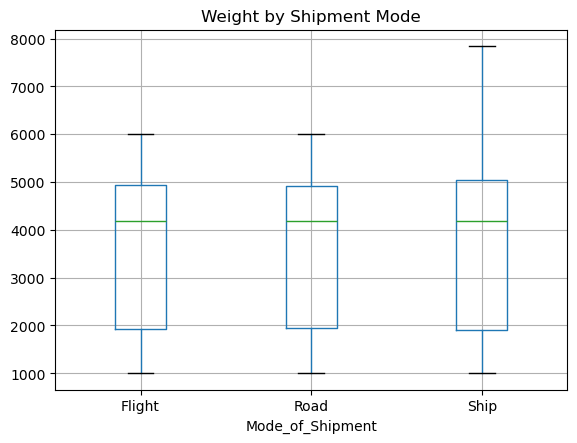

In [84]:
import matplotlib.pyplot as plt

train.boxplot(column='Weight_in_gms', by='Mode_of_Shipment')
plt.title('Weight by Shipment Mode')
plt.suptitle('')
plt.show()

In [85]:
train['Warehouse_block'] = train['Warehouse_block ']
test['Warehouse_block'] = test['Warehouse_block ']

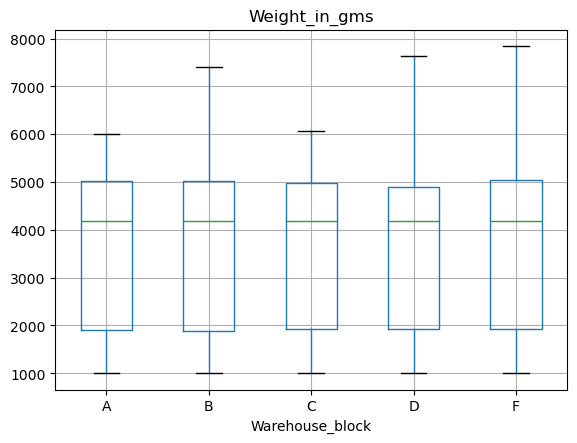

In [86]:
train.groupby('Warehouse_block')['Weight_in_gms'].mean()

train.boxplot(column='Weight_in_gms', by='Warehouse_block')
plt.suptitle('')
plt.show()

In [183]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6999 entries, 1 to 6999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Warehouse_block      6999 non-null   object  
 1   Mode_of_Shipment     6999 non-null   object  
 2   Customer_care_calls  6999 non-null   float64 
 3   Customer_rating      6999 non-null   int64   
 4   Cost_of_the_Product  6999 non-null   int64   
 5   Prior_purchases      6999 non-null   float64 
 6   Product_importance   6999 non-null   object  
 7   Gender               6999 non-null   object  
 8   Discount_offered     6999 non-null   float64 
 9   Weight_in_gms        6999 non-null   float64 
 10  Reached.on.Time_Y.N  6999 non-null   int64   
 11  weight_group         6999 non-null   category
dtypes: category(1), float64(4), int64(3), object(4)
memory usage: 921.3+ KB


## 결측치 채우기 

In [88]:
pd.crosstab(train['Discount_offered'].isnull(),
            train['Reached.on.Time_Y.N'],
            normalize='index')

Reached.on.Time_Y.N,0,1
Discount_offered,,
False,0.404556,0.595444
True,0.406117,0.593883


In [89]:
train['Discount_offered'].describe()

count    3468.000000
mean       13.269031
std        16.070188
min         1.000000
25%         4.000000
50%         7.000000
75%        10.000000
max        65.000000
Name: Discount_offered, dtype: float64

In [90]:
# 결측여부 컬럼 추가
train['Discount_missing'] = train['Discount_offered'].isnull().astype(int)
test['Discount_missing'] = test['Discount_offered'].isnull().astype(int)

median_value = train['Discount_offered'].median()

train['Discount_offered'] = train['Discount_offered'].fillna(median_value)
test['Discount_offered'] = test['Discount_offered'].fillna(median_value)

In [91]:
# 문의 횟수
call_median = train['Customer_care_calls'].median()

train['Customer_care_calls'] = train['Customer_care_calls'].fillna(call_median)
test['Customer_care_calls'] = test['Customer_care_calls'].fillna(call_median)

print(train['Customer_care_calls'].isnull().sum())


# 이전 구매 횟수
prior_median = train['Prior_purchases'].median()

train['Prior_purchases'] = train['Prior_purchases'].fillna(prior_median)
test['Prior_purchases'] = test['Prior_purchases'].fillna(prior_median)

print(train['Prior_purchases'].isnull().sum())

0
0


In [8]:
train.info()
print("===============")
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6999 entries, 1 to 6999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Warehouse_block      6999 non-null   object 
 1   Mode_of_Shipment     6999 non-null   object 
 2   Customer_care_calls  6999 non-null   float64
 3   Customer_rating      6999 non-null   int64  
 4   Cost_of_the_Product  6999 non-null   int64  
 5   Prior_purchases      6999 non-null   float64
 6   Product_importance   6999 non-null   object 
 7   Gender               6999 non-null   object 
 8   Discount_offered     6999 non-null   float64
 9   Weight_in_gms        6999 non-null   float64
 10  Reached.on.Time_Y.N  6999 non-null   int64  
 11  Discount_missing     6999 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 710.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 7000 to 10999
Data columns (total 11 columns):
 #   Column               No

In [93]:
# train['weight_group'] # 없애야 함

train = train.drop('weight_group', axis=1)

## 데이터 분리, 인코딩, 스케일링
- 타겟분리 → train/val 분리 → 인코딩 → 스케일링

In [5]:
# ========= 데이터 분리, 인코딩, 스케일링 =========

# ===== 데이터 분리
y_train = train['Reached.on.Time_Y.N']
X_train = train.drop('Reached.on.Time_Y.N', axis=1)
X_test = test

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)

(6999, 11)
(6999,)
(4000, 11)


In [9]:
X_train = pd.get_dummies(X_train, dtype=int)
X_test = pd.get_dummies(X_test, dtype=int)

In [14]:
### 모델 학습
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=10,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_tr, y_tr)
xgb_pred = model.predict(X_test)

print("Train:", model.score(X_tr, y_tr))
print("Valid:", model.score(X_val, y_val))

C:\Users\agnes\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:10:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train: 0.7644222182532595
Valid: 0.6678571428571428


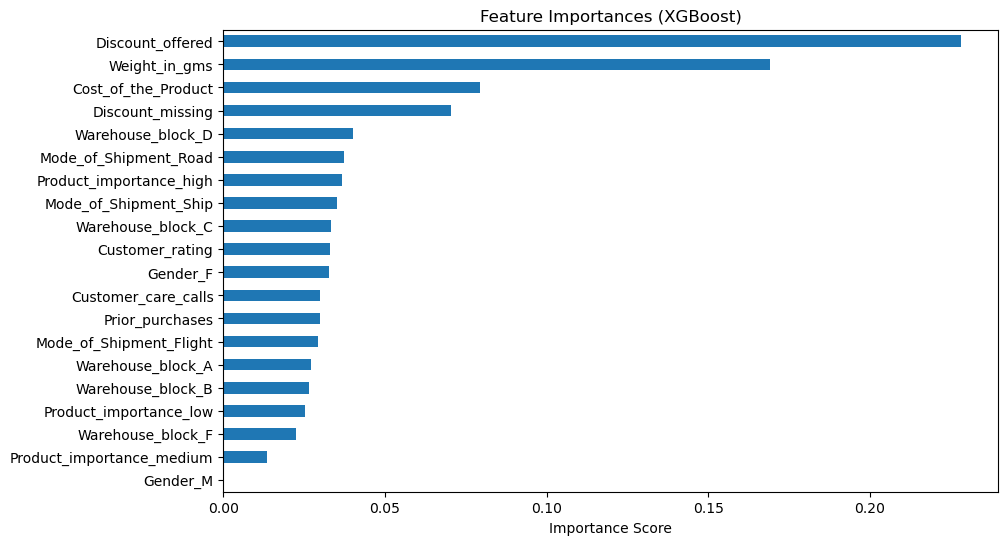

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 중요도 데이터 추출 (반드시 pd.Series 사용!)
# model은 위에서 선언한 XGBClassifier 객체여야 합니다.
importances = pd.Series(model.feature_importances_, index=X_tr.columns)

# 2. 정렬 및 시각화
importances_sorted = importances.sort_values()

plt.figure(figsize=(10, 6))
importances_sorted.plot(kind='barh')
plt.title('Feature Importances (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

In [162]:
print(X_train.shape)
print(X_test.shape)

(6999, 24)
(4000, 24)


In [163]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 모델 선택

### **1) RF사용**

In [125]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, pred))

Train Accuracy: 0.840405772253179


In [126]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model.fit(X_tr, y_tr)

print("Train:", model.score(X_tr, y_tr))
print("Valid:", model.score(X_val, y_val))

Train: 0.8706911948562244
Valid: 0.6728571428571428


In [107]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [1, 5, 10],
    'n_estimators': [100, 200]
}

rf = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_tr, y_tr)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 100}
0.6549371159988464


In [105]:
model.fit(X_train, y_train)
final_pred = model.predict(X_test)
final_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(4000,))

### **2) XGBoost사용**

In [170]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=10,
    use_label_encoder=False,
    eval_metric='logloss'
)

model.fit(X_tr, y_tr)
# xgb_pred = model.predict(X_test)

# print("Train:", model.score(X_tr, y_tr))
# print("Valid:", model.score(X_val, y_val))


# # ========================================
# submission = pd.read_csv('data/26-2/sampleSubmission.csv')

# # 예측결과 덮어쓰기
# submission['Reached.on.Time_Y.N'] = xgb_pred

# # csv 파일 내보내기
# submission.to_csv('sub_xgb_retry.csv', index=False)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## 내보내기

In [ ]:
submission = pd.read_csv('data/26-2/sampleSubmission.csv')

# 예측결과 덮어쓰기
submission['Reached.on.Time_Y.N'] = final_pred

# csv 파일 내보내기
submission.to_csv('sub_RF_retry.csv', index=False)

In [148]:
!pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/100.2 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 2.4/100.2 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 3.7/100.2 MB 6.1 MB/s eta 0:00:16
   - -------------------------------------- 4.7/100.2 MB 5.7 MB/s eta 0:00:17
   -- ------------------------------------- 6.0/100.2 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 7.3/100.2 MB 5.8 MB/s eta 0:00:17
   --- ------------------------------------ 8.7/100.2 MB 5.8 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/100.2 MB 5.8 MB/s eta 0:00:16
   ---- ----------------------------------- 10.7/100.2 MB 5.6 MB/s eta 0:00:17
   ---- ----------------------------------- 11.0/100.2 MB 5.2 MB/s eta 0:00:18
   ---- ----------------------------------- 12.3/100.2 MB 5.3 MB/s eta 0:00

In [1]:
## 기찬님 최근 코드

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train.replace('?', np.nan, inplace=True)
test.replace('?', np.nan, inplace=True)

for col in ['Customer_care_calls', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

train['Discount_offered'] = train['Discount_offered'].fillna(train['Discount_offered'].median())
test['Discount_offered'] = test['Discount_offered'].fillna(train['Discount_offered'].median())

train['Customer_care_calls'] = train['Customer_care_calls'].fillna(train['Customer_care_calls'].median())
test['Customer_care_calls'] = test['Customer_care_calls'].fillna(train['Customer_care_calls'].median())

train['Prior_purchases'] = train['Prior_purchases'].fillna(train['Prior_purchases'].median())
test['Prior_purchases'] = test['Prior_purchases'].fillna(train['Prior_purchases'].median())

def clean_mode(x):
    if pd.isna(x): return 'Ship'
    x = str(x).strip().replace('zk', '')
    if x == '?': return 'Ship'
    return x

train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high', '?': 'low'}
train['Product_importance'] = train['Product_importance'].replace(replace_dict).fillna('low')
test['Product_importance'] = test['Product_importance'].replace(replace_dict).fillna('low')

train['Weight_in_gms'].fillna(train['Weight_in_gms'].median(), inplace=True)
test['Weight_in_gms'].fillna(train['Weight_in_gms'].median(), inplace=True)

train['Warehouse_block'] = train['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])
test['Warehouse_block'] = test['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])

def add_magic_features(df):
    df['Delay_Bomb'] = df['Customer_care_calls'] * df['Discount_offered']
    df['Cost_per_Weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] + 1)
    df['Weight_per_Discount'] = df['Weight_in_gms'] / (df['Discount_offered'] + 1)
    return df

y = train['Reached.on.Time_Y.N'].astype(int)
X = train.drop(['Reached.on.Time_Y.N'], axis=1)
X_test_submit = test.copy()

X = add_magic_features(X)
X_test_submit = add_magic_features(X_test_submit)

# 트리 모델(XGB, LGBM, CatBoost) 라벨 인코딩
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    le = LabelEncoder()
    # Train과 Test를 합쳐서 인코딩
    combined = pd.concat([X[col], X_test_submit[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test_submit[col] = le.transform(X_test_submit[col].astype(str))

print("4. 🚀 3대장 AI(XGB + LGBM + CatBoost) 소환 및 5-Fold 학습 시작...")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros(len(X))
test_probs = np.zeros(len(X_test_submit))

# 3개의 최고급 모델 셋팅
xgb_params = {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.05, 'random_state': 42, 'eval_metric': 'logloss'}
lgbm_params = {'n_estimators': 150, 'max_depth': 6, 'learning_rate': 0.05, 'random_state': 42, 'verbose': -1}
cat_params = {'iterations': 150, 'depth': 6, 'learning_rate': 0.05, 'random_state': 42, 'verbose': 0}

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    # 1. XGBoost
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_tr, y_tr)
    xgb_pred = xgb.predict_proba(X_va)[:, 1]
    
    # 2. LightGBM
    lgb = LGBMClassifier(**lgbm_params)
    lgb.fit(X_tr, y_tr)
    lgb_pred = lgb.predict_proba(X_va)[:, 1]
    
    # 3. CatBoost (범주형 데이터의 최강자)
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X_tr, y_tr)
    cat_pred = cat.predict_proba(X_va)[:, 1]
    
    # 3개 모델의 예측 확률을 평균 내기 (소프트 보팅 앙상블)
    oof_probs[val_idx] = (xgb_pred + lgb_pred + cat_pred) / 3
    
    # 테스트 데이터 예측 누적
    test_probs += (xgb.predict_proba(X_test_submit)[:, 1] + 
                   lgb.predict_proba(X_test_submit)[:, 1] + 
                   cat.predict_proba(X_test_submit)[:, 1]) / 3 / 5

best_acc = 0
best_t = 0.5

# 40% ~ 60% 사이에서 가장 정답률이 높은 커트라인을 찾습니다.
for t in np.arange(0.40, 0.61, 0.01):
    temp_preds = (oof_probs > t).astype(int)
    
    rule_mask = (X['Discount_offered'] > 10) | ((X['Weight_in_gms'] >= 2000) & (X['Weight_in_gms'] <= 4000))
    temp_preds[rule_mask] = 1
    
    score = accuracy_score(y, temp_preds)
    if score > best_acc:
        best_acc = score
        best_t = t


# ==========================================
# 6. 실제 제출 파일 생성 (테스트 데이터도 동일하게 적용)
# ==========================================
final_submit = (test_probs > best_t).astype(int)

# 테스트 데이터에도 절대 법칙 덮어쓰기
test_rule_mask = (test['Discount_offered'] > 10) | ((test['Weight_in_gms'] >= 2000) & (test['Weight_in_gms'] <= 4000))
final_submit[test_rule_mask] = 1

pd.DataFrame({'ID': test.index, 'Reached.on.Time_Y.N': final_submit}).to_csv('Ultimate_70_Master_Submission.csv', index=False)

4. 🚀 3대장 AI(XGB + LGBM + CatBoost) 소환 및 5-Fold 학습 시작...


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import warnings

warnings.filterwarnings('ignore')

# =====================
# 1. 데이터 로드
# =====================
train = pd.read_csv('data/Train.csv', index_col='ID')
test = pd.read_csv('data/test.csv', index_col='ID')

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

train.replace('?', np.nan, inplace=True)
test.replace('?', np.nan, inplace=True)

# =====================
# 2. 숫자형 변환
# =====================
num_cols = ['Customer_care_calls', 'Prior_purchases', 
            'Discount_offered', 'Weight_in_gms']

for col in num_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col] = pd.to_numeric(test[col], errors='coerce')

# 🔥 Discount_missing 먼저 생성
train['Discount_missing'] = train['Discount_offered'].isnull().astype(int)
test['Discount_missing'] = test['Discount_offered'].isnull().astype(int)

# =====================
# 3. 결측 처리 (median)
# =====================
for col in num_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# =====================
# 4. 범주형 정리
# =====================
def clean_mode(x):
    if pd.isna(x): return 'Ship'
    x = str(x).strip().replace('zk', '')
    if x == '?': return 'Ship'
    return x

train['Mode_of_Shipment'] = train['Mode_of_Shipment'].apply(clean_mode)
test['Mode_of_Shipment'] = test['Mode_of_Shipment'].apply(clean_mode)

replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high', '?': 'low'}

train['Product_importance'] = train['Product_importance'].replace(replace_dict).fillna('low')
test['Product_importance'] = test['Product_importance'].replace(replace_dict).fillna('low')

train['Warehouse_block'] = train['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])
test['Warehouse_block'] = test['Warehouse_block'].fillna(train['Warehouse_block'].mode()[0])

# =====================
# 5. 파생변수
# =====================
def add_magic_features(df):
    df['Delay_Bomb'] = df['Customer_care_calls'] * df['Discount_offered']
    df['Cost_per_Weight'] = df['Cost_of_the_Product'] / (df['Weight_in_gms'] + 1)
    df['Weight_per_Discount'] = df['Weight_in_gms'] / (df['Discount_offered'] + 1)
    return df

y = train['Reached.on.Time_Y.N'].astype(int)
X = train.drop(['Reached.on.Time_Y.N'], axis=1)
X_test_submit = test.copy()

X = add_magic_features(X)
X_test_submit = add_magic_features(X_test_submit)

# =====================
# 6. 라벨 인코딩
# =====================
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test_submit[col]]).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test_submit[col] = le.transform(X_test_submit[col].astype(str))

# =====================
# 7. 모델 파라미터 업그레이드
# =====================
xgb_params = {
    'n_estimators': 700,
    'max_depth': 6,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
}

lgbm_params = {
    'n_estimators': 700,
    'max_depth': -1,
    'learning_rate': 0.03,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'verbose': -1
}

cat_params = {
    'iterations': 700,
    'depth': 6,
    'learning_rate': 0.03,
    'random_state': 42,
    'verbose': 0
}

# =====================
# 8. 5-Fold CV
# =====================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = np.zeros(len(X))
test_probs = np.zeros(len(X_test_submit))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
    
    xgb = XGBClassifier(**xgb_params)
    lgb = LGBMClassifier(**lgbm_params)
    cat = CatBoostClassifier(**cat_params)
    
    xgb.fit(X_tr, y_tr)
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    
    xgb_pred = xgb.predict_proba(X_va)[:, 1]
    lgb_pred = lgb.predict_proba(X_va)[:, 1]
    cat_pred = cat.predict_proba(X_va)[:, 1]
    
    # 🔥 가중 앙상블 (XGB 비중 조금 더)
    fold_pred = 0.4*xgb_pred + 0.3*lgb_pred + 0.3*cat_pred
    
    # 🔥 룰은 validation에만 적용
    rule_mask = (
        (X_va['Discount_offered'] > 9) |
        ((X_va['Weight_in_gms'] >= 1800) & (X_va['Weight_in_gms'] <= 4200))
    )
    
    fold_pred[rule_mask] = 1
    
    oof_probs[val_idx] = fold_pred
    
    # 테스트 누적
    test_probs += (
        0.4*xgb.predict_proba(X_test_submit)[:, 1] +
        0.3*lgb.predict_proba(X_test_submit)[:, 1] +
        0.3*cat.predict_proba(X_test_submit)[:, 1]
    ) / 5

# =====================
# 9. 최적 threshold 탐색
# =====================
best_acc = 0
best_t = 0.5

for t in np.arange(0.40, 0.61, 0.01):
    temp_preds = (oof_probs > t).astype(int)
    score = accuracy_score(y, temp_preds)
    if score > best_acc:
        best_acc = score
        best_t = t

print("Best CV:", best_acc)
print("Best Threshold:", best_t)

# =====================
# 10. 제출 파일 생성
# =====================
final_submit = (test_probs > best_t).astype(int)

# 테스트 룰 적용
test_rule_mask = (
    (X_test_submit['Discount_offered'] > 9) |
    ((X_test_submit['Weight_in_gms'] >= 1800) & 
     (X_test_submit['Weight_in_gms'] <= 4200))
)

final_submit[test_rule_mask] = 1

pd.DataFrame({
    'ID': test.index,
    'Reached.on.Time_Y.N': final_submit
}).to_csv('Ultimate_Upgraded_Submission.csv', index=False)

print("🔥 업그레이드 제출 파일 생성 완료!")

## 다항회귀를 써볼까? 

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. 데이터 로드
train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')

# 2. 전처리 함수 만들기 (Train, Test 둘 다 똑같이 적용하려고!)
def preprocess_data(df, is_train=True, train_medians=None):
    df = df.copy()
    df.columns = df.columns.str.strip() # 공백 제거
    
    # [결측치 & 오타 처리] 네가 짰던 로직 그대로!
    df['Discount_missing'] = df['Discount_offered'].isnull().astype(int)
    
    # 숫자는 median으로 (Train의 기준을 Test에 써야 함)
    if is_train:
        medians = {
            'discount': df['Discount_offered'].median(),
            'calls': df['Customer_care_calls'].median(),
            'prior': df['Prior_purchases'].median(),
            'weight': pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').median()
        }
    else:
        medians = train_medians

    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce')
    df['Weight_in_gms'] = df['Weight_in_gms'].fillna(medians['weight'])

    # 오타 수정
    def clean_mode(x):
        if isinstance(x, str):
            x = x.strip().replace('zk', '')
            return 'Ship' if x == '?' else x
        return x
    df['Mode_of_Shipment'] = df['Mode_of_Shipment'].apply(clean_mode)
    
    replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high'}
    df['Product_importance'] = df['Product_importance'].replace(replace_dict)
    
    # '?' 처리 (Train의 최빈값을 쓰거나, 그냥 특정값으로)
    if is_train:
        imp_mode = df[df['Product_importance'] != '?']['Product_importance'].mode()[0]
        medians['imp_mode'] = imp_mode
    else:
        imp_mode = medians['imp_mode']
    df['Product_importance'] = df['Product_importance'].replace('?', imp_mode)

    return df, medians

# 3. 데이터 준비
train_cleaned, train_medians = preprocess_data(train, is_train=True)
test_cleaned, _ = preprocess_data(test, is_train=False, train_medians=train_medians)

X_train = train_cleaned.drop('Reached.on.Time_Y.N', axis=1)
y_train = train_cleaned['Reached.on.Time_Y.N']
X_test = test_cleaned # Test는 정답 컬럼이 원래 없지?

# 4. 파이프라인 설정 (다항 특징 + 스케일링 + 모델)
num_features = ['Cost_of_the_Product', 'Discount_offered', 'Weight_in_gms', 'Customer_care_calls', 'Prior_purchases']
cat_features = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('poly', PolynomialFeatures(degree=2)), ('scaler', StandardScaler())]), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

model_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# 5. 학습 및 Test 데이터 예측
model_pipeline.fit(X_train, y_train)
final_predictions = model_pipeline.predict_proba(X_test)[:, 1] # 확률값으로 추출!



submission = pd.read_csv('data/26-2/sampleSubmission.csv')

# 예측결과 덮어쓰기
submission['Reached.on.Time_Y.N'] = final_predictions

# csv 파일 내보내기
submission.to_csv('sub_add_col.csv', index=False)

## 다시 XGB

In [8]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier 
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 데이터 로드
# 파일 경로는 네 환경에 맞게 유지했어!
train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')

# # 2. 전처리 함수 (에러 수정 및 특징 추가 통합)
def preprocess_data(df, is_train=True, train_medians=None):
    df = df.copy()
    df.columns = df.columns.str.strip()
    
    # [결측치 & 오타 처리]
    df['Discount_missing'] = df['Discount_offered'].isnull().astype(int)
    
    if is_train:
        medians = {
            'discount': df['Discount_offered'].median(),
            'calls': df['Customer_care_calls'].median(),
            'prior': df['Prior_purchases'].median(),
            'weight': pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').median(),
            'imp_mode': df[df['Product_importance'] != '?']['Product_importance'].mode()[0]
        }
    else:
        medians = train_medians

    # 수치형 결측치 채우기
    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').fillna(medians['weight'])
    
    # 2. [강력한 파생 변수 추가]
    # (1) 무게 대비 가격 (가물치 지표: 무거운데 싸면 배송이 늦어질 확률이 큼)
    df['Weight_Cost_Ratio'] = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)
    
    # (2) 할인율 10%의 벽 (이 데이터셋의 가장 강력한 구분선)
    df['Is_High_Discount'] = (df['Discount_offered'] > 10).astype(int)
    df['Discount_Diff_10'] = (df['Discount_offered'] - 10).abs()
    
    # (3) 고객 피로도 (전화 횟수와 이전 구매 빈도의 조합)
    df['Customer_Fatigue'] = df['Customer_care_calls'] * df['Prior_purchases']

    # 3. [노이즈 변수 제거] - 중요도가 낮아 점수를 깎아먹는 변수들
    # Gender는 분석 결과 영향력이 거의 없으므로 과감히 제거합니다.
    # ID는 이미 인덱스로 설정되어 있을 것이므로 drop 목록에 추가해도 무방합니다.
    drop_features = ['Gender']
    df = df.drop(columns=[col for col in drop_features if col in df.columns])

    # 4. [범주형 오타 수정 및 인코딩]
    replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high'}
    df['Product_importance'] = df['Product_importance'].replace(replace_dict).replace('?', medians['imp_mode'])
    df['Mode_of_Shipment'] = df['Mode_of_Shipment'].replace('?', 'Ship').str.replace('zk', '', regex=False).str.strip()

    # 원-핫 인코딩 (범주형 컬럼만 선택)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'])

    return df, medians



# 3. 데이터 준비
train_cleaned, train_medians = preprocess_data(train, is_train=True)
test_cleaned, _ = preprocess_data(test, is_train=False, train_medians=train_medians)

# 4. 학습/검증 데이터 분리
# Train과 Test의 컬럼 순서를 똑같이 맞춰줍니다.
X = train_cleaned.drop('Reached.on.Time_Y.N', axis=1)
y = train_cleaned['Reached.on.Time_Y.N']

# (수정 포인트: X_train 정의 시 전체 X를 썼는지 확인!)
X_train_full, X_val, y_train_full, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. XGBoost 모델 설정
# 에러 메시지를 없애고 성능을 더 높인 XGBoost 설정
xgb_model = XGBClassifier(
    n_estimators=300,        # 공부 횟수를 조금 더 늘려봐요
    learning_rate=0.02,      # 더 천천히, 꼼꼼하게 공부하게 해요
    max_depth=4,             # 너무 깊으면 외워버리니까 적당히!
    min_child_weight=1,      # 한 그룹에 최소 몇 명이 있을지 결정 (작을수록 꼼꼼함)
    subsample=0.8,           # 데이터의 80%만 무작위로 써서 공부 (다양성 확보)
    colsample_bytree=0.8,    # 특징(칼럼)도 80%만 무작위로 써요
    random_state=42,
    use_label_encoder=False, # 이제 이 줄은 빼도 되지만 일단 둠
    eval_metric='logloss'
)

# 6. 학습 시작
xgb_model.fit(X_train_full, y_train_full)

# 7. 새로운 예상 점수 확인
xgb_pred_probs = xgb_model.predict_proba(X_val)[:, 1]
new_auc = roc_auc_score(y_val, xgb_pred_probs)

print(f"--- 🏆 엔진 교체 후 결과 ---")
print(f"새로운 예상 AUC 점수: {new_auc:.4f}")

--- 🏆 엔진 교체 후 결과 ---
새로운 예상 AUC 점수: 0.7381


## XGB + RF

In [20]:
from sklearn.ensemble import RandomForestClassifier

# 1. XGBoost 모델 (이미 0.7359를 찍은 그 설정!)
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

# 2. Random Forest 모델 (안정감을 더해주는 친구)
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,      # 나무가 너무 무한정 자라지 않게 조절
    random_state=42
)

# 3. 두 모델 각각 학습시키기
print("XGBoost 학습 중...")
xgb_model.fit(X_train_full, y_train_full)

print("Random Forest 학습 중...")
rf_model.fit(X_train_full, y_train_full)

# 4. 검증 데이터로 '섞기(Ensemble)' 점수 확인
xgb_val_probs = xgb_model.predict_proba(X_val)[:, 1]
rf_val_probs = rf_model.predict_proba(X_val)[:, 1]

# # 7:3 비율로 섞기 (이 비율은 네가 조금씩 바꿔보며 실험해봐도 돼!)
# ensemble_val_probs = (xgb_val_probs * 0.7) + (rf_val_probs * 0.3)

# ensemble_auc = roc_auc_score(y_val, ensemble_val_probs)
# print(f"\n--- 🏆 앙상블 결과 ---")
# print(f"최종 예상 AUC 점수: {ensemble_auc:.4f}")

# 1. 여러 비율로 테스트해보기
ratios = [0.9, 0.85, 0.8, 0.75]

for r in ratios:
    mix = (xgb_val_probs * r) + (rf_val_probs * (1-r))
    score = roc_auc_score(y_val, mix)
    print(f"XGB 비율 {r} : RF 비율 {1-r:.2f} -> AUC: {score:.4f}")

XGBoost 학습 중...
Random Forest 학습 중...
XGB 비율 0.9 : RF 비율 0.10 -> AUC: 0.7309
XGB 비율 0.85 : RF 비율 0.15 -> AUC: 0.7311
XGB 비율 0.8 : RF 비율 0.20 -> AUC: 0.7310
XGB 비율 0.75 : RF 비율 0.25 -> AUC: 0.7312


## LGBM.... 전체 코드....

In [14]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 데이터 로드
train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')

# 2. 전처리 함수 
def preprocess_data(df, is_train=True, train_medians=None):
    df = df.copy()
    df.columns = df.columns.str.strip()
    
    # [결측치 & 오타 처리]
    df['Discount_missing'] = df['Discount_offered'].isnull().astype(int)
    
    if is_train:
        medians = {
            'discount': df['Discount_offered'].median(),
            'calls': df['Customer_care_calls'].median(),
            'prior': df['Prior_purchases'].median(),
            'weight': pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').median(),
            'imp_mode': df[df['Product_importance'] != '?']['Product_importance'].mode()[0]
        }
    else:
        medians = train_medians

    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').fillna(medians['weight'])
    
   # 수치형 결측치 채우기
    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').fillna(medians['weight'])
    
    # 2. [강력한 파생 변수 추가]
    # (1) 무게 대비 가격 (가물치 지표: 무거운데 싸면 배송이 늦어질 확률이 큼)
    df['Weight_Cost_Ratio'] = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)
    
    # (2) 할인율 10%의 벽 (이 데이터셋의 가장 강력한 구분선)
    df['Is_High_Discount'] = (df['Discount_offered'] > 10).astype(int)
    df['Discount_Diff_10'] = (df['Discount_offered'] - 10).abs()
    
    # (3) 고객 피로도 (전화 횟수와 이전 구매 빈도의 조합)
    df['Customer_Fatigue'] = df['Customer_care_calls'] * df['Prior_purchases']

    # 3. [노이즈 변수 제거] - 중요도가 낮아 점수를 깎아먹는 변수들
    # Gender는 분석 결과 영향력이 거의 없으므로 과감히 제거합니다.
    # ID는 이미 인덱스로 설정되어 있을 것이므로 drop 목록에 추가해도 무방합니다.
    drop_features = ['Gender']
    df = df.drop(columns=[col for col in drop_features if col in df.columns])

    # 4. [범주형 오타 수정 및 인코딩]
    replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high'}
    df['Product_importance'] = df['Product_importance'].replace(replace_dict).replace('?', medians['imp_mode'])
    df['Mode_of_Shipment'] = df['Mode_of_Shipment'].replace('?', 'Ship').str.replace('zk', '', regex=False).str.strip()

    # 원-핫 인코딩 (범주형 컬럼만 선택)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'])

    return df, medians

# 3. 데이터 준비 및 컬럼 맞추기
train_cleaned, train_medians = preprocess_data(train, is_train=True)
test_cleaned, _ = preprocess_data(test, is_train=False, train_medians=train_medians)

X = train_cleaned.drop('Reached.on.Time_Y.N', axis=1)
y = train_cleaned['Reached.on.Time_Y.N']

# Test 데이터의 컬럼 순서를 Train과 똑같이 맞춰줍니다.
test_cleaned = test_cleaned.reindex(columns=X.columns, fill_value=0)


# 4. 검증을 위한 분리 (점수 확인용)
X_train_full, X_val, y_train_full, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. 에이스 모델(LightGBM) 학습
lgbm_model = LGBMClassifier(
    n_estimators=1000, # 넉넉히 주고
    learning_rate=0.01,
    max_depth=5,
    num_leaves=31,
    random_state=42,
    importance_type='gain'
)

print("🚀 LightGBM 에이스 특훈 시작...")
lgbm_model.fit(X_train_full, y_train_full)

# 6. 점수 확인
val_probs = lgbm_model.predict_proba(X_val)[:, 1]
print(f"--- 🏆 검증 결과 ---")
print(f"최종 LightGBM AUC: {roc_auc_score(y_val, val_probs):.4f}")

# 7. 진짜 정답 예측 및 제출 파일 만들기
final_test_preds = lgbm_model.predict(test_cleaned)

# 방법 2: 기존 확률 값을 기준으로 변환 (임계값 조절 가능)
# final_test_probs = lgbm_model.predict_proba(test_cleaned)[:, 1]


submission = pd.read_csv('data/26-2/sampleSubmission.csv')

# 예측결과 덮어쓰기
submission['Reached.on.Time_Y.N'] = final_test_preds

# csv 파일 내보내기
submission.to_csv('sub_LGBM.csv', index=False)

🚀 LightGBM 에이스 특훈 시작...
--- 🏆 검증 결과 ---
최종 LightGBM AUC: 0.7351


In [22]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# 1. 데이터 로드
train = pd.read_csv('data/26-2/Train.csv', index_col='ID')
test = pd.read_csv('data/26-2/test.csv', index_col='ID')

# 2. 전처리 함수 
def preprocess_data(df, is_train=True, train_medians=None):
    df = df.copy()
    df.columns = df.columns.str.strip()
    
    # [결측치 & 오타 처리]
    df['Discount_missing'] = df['Discount_offered'].isnull().astype(int)
    
    if is_train:
        medians = {
            'discount': df['Discount_offered'].median(),
            'calls': df['Customer_care_calls'].median(),
            'prior': df['Prior_purchases'].median(),
            'weight': pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').median(),
            'imp_mode': df[df['Product_importance'] != '?']['Product_importance'].mode()[0]
        }
    else:
        medians = train_medians

    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').fillna(medians['weight'])
    
   # 수치형 결측치 채우기
    df['Discount_offered'] = df['Discount_offered'].fillna(medians['discount'])
    df['Customer_care_calls'] = df['Customer_care_calls'].fillna(medians['calls'])
    df['Prior_purchases'] = df['Prior_purchases'].fillna(medians['prior'])
    df['Weight_in_gms'] = pd.to_numeric(df['Weight_in_gms'].replace('?', np.nan), errors='coerce').fillna(medians['weight'])
    
    # 2. [강력한 파생 변수 추가]
    # (1) 무게 대비 가격 (가물치 지표: 무거운데 싸면 배송이 늦어질 확률이 큼)
    df['Weight_Cost_Ratio'] = df['Weight_in_gms'] / (df['Cost_of_the_Product'] + 1)
    
    # (2) 할인율 10%의 벽 (이 데이터셋의 가장 강력한 구분선)
    df['Is_High_Discount'] = (df['Discount_offered'] > 10).astype(int)
    df['Discount_Diff_10'] = (df['Discount_offered'] - 10).abs()
    
    # (3) 고객 피로도 (전화 횟수와 이전 구매 빈도의 조합)
    df['Customer_Fatigue'] = df['Customer_care_calls'] * df['Prior_purchases']

    # =============== 3. [노이즈 변수 제거] - 중요도가 낮아 점수를 깎아먹는 변수들
    # Gender는 분석 결과 영향력이 거의 없으므로 과감히 제거합니다.
    # ID는 이미 인덱스로 설정되어 있을 것이므로 drop 목록에 추가해도 무방합니다.
    drop_features = ['Gender', 'Discount_missing'] # Discount_missing이 큰 효과 없으면 여기서 삭제
    df = df.drop(columns=[col for col in drop_features if col in df.columns])

    # 4. [범주형 정제 및 인코딩]
    # 4. [범주형 오타 수정 및 인코딩]
    replace_dict = {'loww': 'low', 'mediumm': 'medium', 'highh': 'high'}
    df['Product_importance'] = df['Product_importance'].replace(replace_dict).replace('?', medians['imp_mode'])
    df['Mode_of_Shipment'] = df['Mode_of_Shipment'].replace('?', 'Ship').str.replace('zk', '', regex=False).str.strip()

    # 원-핫 인코딩 (범주형 컬럼만 선택)
    df = pd.get_dummies(df, columns=['Warehouse_block', 'Mode_of_Shipment', 'Product_importance'])

    return df, medians

# 3. 데이터 준비 및 컬럼 맞추기
train_cleaned, train_medians = preprocess_data(train, is_train=True)
test_cleaned, _ = preprocess_data(test, is_train=False, train_medians=train_medians)

X = train_cleaned.drop('Reached.on.Time_Y.N', axis=1)
y = train_cleaned['Reached.on.Time_Y.N']

# Test 데이터의 컬럼 순서를 Train과 똑같이 맞춰줍니다.
test_cleaned = test_cleaned.reindex(columns=X.columns, fill_value=0)


# 4. 검증을 위한 분리 (점수 확인용)
X_train_full, X_val, y_train_full, y_val = train_test_split(X, y, test_size=0.3, random_state=42)


from sklearn.model_selection import StratifiedKFold

# 4-6. K-Fold 교차 검증 및 학습
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 폴드별 결과를 저장할 리스트
oof_auc_scores = []  # 검증 점수 저장
test_preds_list = [] # 테스트 데이터 예측 확률 저장

print("🚀 5-Fold 에이스 특훈 시작...")

for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # 모델 정의 (매 폴드마다 새로 생성)
    model = LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        max_depth=7,            # 5 or 6 -> 7 (조금 더 복잡한 관계 학습)
        num_leaves=63,          # 31 -> 63 (트리의 노드 수를 늘려 표현력 강화)
        min_child_samples=30,   # 과적합 방지를 위해 한 노드에 최소 데이터 수 지정
        subsample=0.8,          # 데이터의 80%만 무작위 사용 (일반화 성능 향상)
        colsample_bytree=0.8,   # 변수의 80%만 무작위 사용
        random_state=42,
        importance_type='gain',
        verbose=-1
    )
    
    # 학습
    model.fit(X_train_fold, y_train_fold)
    
    # 검증 데이터 확률 예측 및 AUC 계산
    val_probs = model.predict_proba(X_val_fold)[:, 1]
    score = roc_auc_score(y_train_fold == y_train_fold, val_probs) # 실제 y_val_fold 사용
    score = roc_auc_score(y_val_fold, val_probs)
    oof_auc_scores.append(score)
    
    # 테스트 데이터에 대한 확률 예측 저장
    test_probs = model.predict_proba(test_cleaned)[:, 1]
    test_preds_list.append(test_probs)
    
    print(f"Fold {i+1} AUC: {score:.4f}")

# 최종 결과 분석
print(f"\n--- 🏆 최종 검증 결과 ---")
print(f"5-Fold 평균 AUC: {np.mean(oof_auc_scores):.4f}")

# 7. 진짜 정답 예측 (5개 모델의 예측치를 평균냄)
final_test_avg_probs = np.mean(test_preds_list, axis=0)

# 제출용 0, 1 변환 (0.5 기준)
final_test_preds = (final_test_avg_probs > 0.5).astype(int)


# 제출 파일 만들기
submission = pd.read_csv('data/26-2/sampleSubmission.csv')

# 예측결과 덮어쓰기
submission['Reached.on.Time_Y.N'] = final_test_preds

# csv 파일 내보내기
submission.to_csv('sub_LGBM_last.csv', index=False)

🚀 5-Fold 에이스 특훈 시작...
Fold 1 AUC: 0.7153
Fold 2 AUC: 0.7406
Fold 3 AUC: 0.7395
Fold 4 AUC: 0.7511
Fold 5 AUC: 0.7478

--- 🏆 최종 검증 결과 ---
5-Fold 평균 AUC: 0.7389


In [6]:
lgbm_model.feature_importances_

array([8.08929072e+02, 7.87461031e+02, 1.46537820e+04, 1.07485503e+03,
       2.70195216e+04, 4.44909954e+04, 1.28291080e+03, 2.98622423e+03,
       5.33730388e+01, 4.30819303e+01, 1.86820860e+02, 9.06686797e+01,
       1.20257868e+02, 5.44734160e+02, 1.35123107e+02, 1.78445599e+01,
       1.40498666e+02, 7.18695406e+01, 1.18730944e+02, 2.13545721e+01,
       1.77884386e+02, 5.44900341e-07])

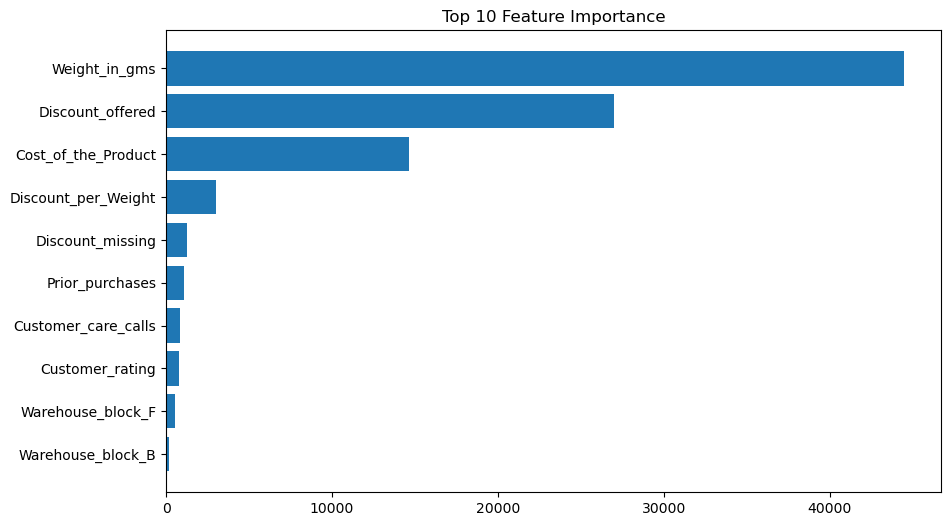

In [7]:
import matplotlib.pyplot as plt

# 변수 중요도를 데이터프레임으로 변환
fi = pd.DataFrame({'feature': X.columns, 'importance': lgbm_model.feature_importances_})
fi = fi.sort_values('importance', ascending=False)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(fi['feature'][:10], fi['importance'][:10])
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importance')
plt.show()

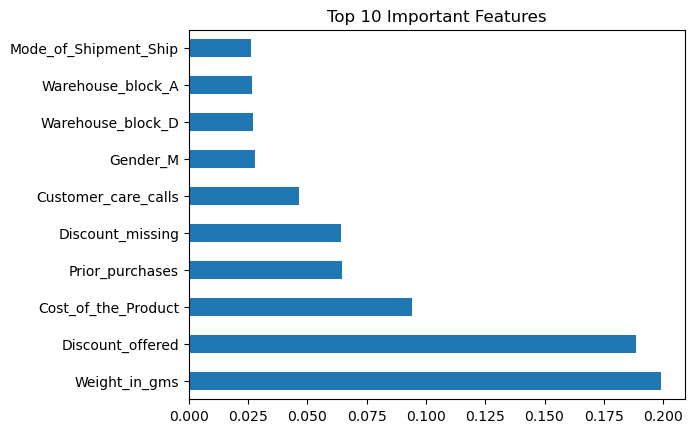

In [13]:
import matplotlib.pyplot as plt

# 어떤 변수가 가장 중요한지 그려보기
importances = pd.Series(xgb_model.feature_importances_, index=X_train_full.columns)
importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Important Features')
plt.show()

In [26]:
# 형선님 코드

# !pip install optuna -q

# ============================================================
# 최종 파이프라인 - 과적합 해결 + XGB/LGBM + Optuna 튜닝
# pip install xgboost lightgbm optuna
# ============================================================

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ============================================================
# STEP 1. 데이터 로드
# ============================================================
train = pd.read_csv('data/26-2/Train.csv')
test = pd.read_csv('data/26-2/test.csv')

# ============================================================
# STEP 2. 전처리
# ============================================================
train.columns = train.columns.str.strip()
test.columns  = test.columns.str.strip()

train['Weight_in_gms'] = pd.to_numeric(train['Weight_in_gms'], errors='coerce')
test['Weight_in_gms']  = pd.to_numeric(test['Weight_in_gms'],  errors='coerce')

def clean_shipment(val):
    if not isinstance(val, str): return np.nan
    v = val.strip()
    if v in ('Shipzk',):   return 'Ship'
    if v in ('Flightzk',): return 'Flight'
    if v in ('Roadzk',):   return 'Road'
    if v in ('Ship', 'Flight', 'Road'): return v
    return np.nan

def clean_importance(val):
    if not isinstance(val, str): return np.nan
    v = val.strip().lower()
    if v in ('loww',):    return 'low'
    if v in ('mediumm',): return 'medium'
    if v in ('highh',):   return 'high'
    if v in ('low', 'medium', 'high'): return v
    return np.nan

for df in [train, test]:
    df['Mode_of_Shipment']   = df['Mode_of_Shipment'].apply(clean_shipment)
    df['Product_importance'] = df['Product_importance'].apply(clean_importance)

TARGET   = 'Reached.on.Time_Y.N'
FEATURES = [c for c in train.columns if c not in ['ID', TARGET]]
X      = train[FEATURES].copy()
y      = train[TARGET].copy()
X_test = test[FEATURES].copy()
test_ids = test['ID']

# ============================================================
# STEP 3. 피처 엔지니어링
# ============================================================
def feature_engineering(df):
    df = df.copy()
    df['discount_bucket'] = pd.cut(
        df['Discount_offered'].fillna(0),
        bins=[-1, 0, 10, 30, 65, 100],
        labels=['no_discount', 'low', 'mid', 'high', 'very_high']
    ).astype(str)
    df['weight_bucket'] = pd.cut(
        df['Weight_in_gms'].fillna(df['Weight_in_gms'].median()),
        bins=[0, 2000, 4000, 7000],
        labels=['light', 'medium', 'heavy']
    ).astype(str)
    df['care_x_rating']  = df['Customer_care_calls'].fillna(0) * df['Customer_rating']
    df['discount_ratio'] = df['Discount_offered'].fillna(0) / (df['Cost_of_the_Product'] + 1)
    df['is_loyal']       = (df['Prior_purchases'].fillna(0) >= 4).astype(int)
    return df

X      = feature_engineering(X)
X_test = feature_engineering(X_test)

num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# ============================================================
# STEP 4. 전처리 파이프라인
# ============================================================
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ============================================================
# STEP 5. 과적합 진단
# ============================================================
print("=" * 50)
print("  [과적합 진단] 기본 모델 기준")
print("=" * 50)

base_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(n_estimators=300, max_depth=6, random_state=42,
                             use_label_encoder=False, eval_metric='logloss', n_jobs=-1))
])
base_xgb.fit(X_train, y_train)

train_score = base_xgb.score(X_train, y_train)
val_score   = base_xgb.score(X_val,   y_val)
gap         = train_score - val_score

print(f"  Train Accuracy : {train_score:.4f} ({train_score*100:.2f}%)")
print(f"  Val Accuracy   : {val_score:.4f}   ({val_score*100:.2f}%)")
print(f"  Gap            : {gap:.4f}  {'⚠️ 과적합 심각' if gap > 0.1 else '⚠️ 과적합 의심' if gap > 0.05 else '✅ 정상'}")

# ============================================================
# STEP 6. Optuna 튜닝 - 과적합 억제 파라미터 탐색
#
# [과적합 해결 전략]
# 1. max_depth 줄이기        → 나무가 너무 깊게 자라는 것 방지
# 2. min_child_weight 높이기 → 너무 소수 샘플에 과하게 맞추는 것 방지
# 3. gamma / reg_alpha / reg_lambda → 정규화로 과도한 학습 억제
# 4. subsample / colsample 낮추기  → 매 나무마다 데이터/피처 일부만 사용
# 5. learning_rate 낮추기    → 천천히 학습해서 안정적인 일반화
# ============================================================
print("\n[STEP 6] Optuna 튜닝 시작 (50 trials)...")
print("  → 과적합 억제 파라미터 중심으로 탐색")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective(trial):
    xgb_params = dict(
        n_estimators     = trial.suggest_int('xgb_n_est', 100, 600),
        max_depth        = trial.suggest_int('xgb_depth', 2, 5),        # 얕게 제한 (과적합 방지)
        learning_rate    = trial.suggest_float('xgb_lr', 0.01, 0.1, log=True),
        subsample        = trial.suggest_float('xgb_sub', 0.5, 0.85),   # 낮게 제한
        colsample_bytree = trial.suggest_float('xgb_col', 0.5, 0.85),
        min_child_weight = trial.suggest_int('xgb_mcw', 5, 20),         # 높게 제한 (과적합 방지)
        gamma            = trial.suggest_float('xgb_gamma', 0.1, 1.0),  # 정규화
        reg_alpha        = trial.suggest_float('xgb_alpha', 0.1, 5.0),  # L1 정규화
        reg_lambda       = trial.suggest_float('xgb_lambda', 1.0, 10.0),# L2 정규화
        use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
    )
    lgbm_params = dict(
        n_estimators      = trial.suggest_int('lgbm_n_est', 100, 600),
        max_depth         = trial.suggest_int('lgbm_depth', 2, 5),      # 얕게 제한
        learning_rate     = trial.suggest_float('lgbm_lr', 0.01, 0.1, log=True),
        num_leaves        = trial.suggest_int('lgbm_leaves', 10, 31),   # 낮게 제한
        subsample         = trial.suggest_float('lgbm_sub', 0.5, 0.85),
        colsample_bytree  = trial.suggest_float('lgbm_col', 0.5, 0.85),
        min_child_samples = trial.suggest_int('lgbm_mcs', 30, 100),     # 높게 제한 (과적합 방지)
        reg_alpha         = trial.suggest_float('lgbm_alpha', 0.1, 5.0),
        reg_lambda        = trial.suggest_float('lgbm_lambda', 1.0, 10.0),
        random_state=42, n_jobs=-1, verbose=-1
    )

    ensemble = VotingClassifier(
        estimators=[
            ('xgb',  XGBClassifier(**xgb_params)),
            ('lgbm', LGBMClassifier(**lgbm_params)),
        ],
        voting='soft'
    )
    pipe = Pipeline([('preprocessor', preprocessor), ('model', ensemble)])

    # CV 점수와 Train 점수 차이(gap)도 함께 패널티로 반영
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    pipe.fit(X_train, y_train)
    train_acc = pipe.score(X_train, y_train)
    val_acc   = pipe.score(X_val, y_val)
    gap_penalty = max(0, train_acc - val_acc - 0.05)  # gap 0.05 초과분 패널티

    return cv_scores.mean() - gap_penalty              # 과적합 억제하면서 CV 높이기

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n  Best Score : {study.best_value:.4f}")
print(f"  Best Params:\n")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# ============================================================
# STEP 7. 최적 파라미터로 최종 모델 구성
# ============================================================
bp = study.best_params

best_xgb = XGBClassifier(
    n_estimators=bp['xgb_n_est'], max_depth=bp['xgb_depth'],
    learning_rate=bp['xgb_lr'], subsample=bp['xgb_sub'],
    colsample_bytree=bp['xgb_col'], min_child_weight=bp['xgb_mcw'],
    gamma=bp['xgb_gamma'], reg_alpha=bp['xgb_alpha'], reg_lambda=bp['xgb_lambda'],
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
)
best_lgbm = LGBMClassifier(
    n_estimators=bp['lgbm_n_est'], max_depth=bp['lgbm_depth'],
    learning_rate=bp['lgbm_lr'], num_leaves=bp['lgbm_leaves'],
    subsample=bp['lgbm_sub'], colsample_bytree=bp['lgbm_col'],
    min_child_samples=bp['lgbm_mcs'],
    reg_alpha=bp['lgbm_alpha'], reg_lambda=bp['lgbm_lambda'],
    random_state=42, n_jobs=-1, verbose=-1
)

final_ensemble = VotingClassifier(
    estimators=[('xgb', best_xgb), ('lgbm', best_lgbm)],
    voting='soft', weights=[1, 1]
)
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        final_ensemble)
])

# ============================================================
# STEP 8. 최종 성능 평가
# ============================================================
final_pipeline.fit(X_train, y_train)

train_score = final_pipeline.score(X_train, y_train)
val_score   = final_pipeline.score(X_val,   y_val)
gap         = train_score - val_score
y_pred      = final_pipeline.predict(X_val)
y_proba     = final_pipeline.predict_proba(X_val)[:, 1]
auc         = roc_auc_score(y_val, y_proba)

cv_scores = cross_val_score(final_pipeline, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("\n" + "=" * 50)
print("  [최종 성능 평가] 튜닝 후")
print("=" * 50)
print(f"  Train Accuracy : {train_score:.4f} ({train_score*100:.2f}%)")
print(f"  Val Accuracy   : {val_score:.4f}   ({val_score*100:.2f}%)")
print(f"  Gap            : {gap:.4f}  {'⚠️ 과적합 의심' if gap > 0.05 else '✅ 정상'}")
print(f"  ROC-AUC        : {auc:.4f}")
print(f"\n  CV 평균        : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  각 Fold        : {[round(s,4) for s in cv_scores]}")
print()
print("  Classification Report:")
print(classification_report(y_val, y_pred, target_names=['정시(0)', '지연(1)']))

# ============================================================
# STEP 9. 전체 데이터로 재학습 후 submission 생성
# ============================================================

print("[Final] 전체 데이터로 재학습 후 submission 생성...")
final_pipeline.fit(X, y)

# 1. 예측값 생성
y_test_pred = final_pipeline.predict(X_test)

# 2. 샘플 파일을 불러와서 값만 덮어씌우기 (추천 방식)
submission = pd.read_csv('data/26-2/sampleSubmission.csv')
submission['Reached.on.Time_Y.N'] = y_test_pred

# 3. 저장
submission.to_csv('submission_final_CCC.csv', index=False)

print("✅ submission.csv 생성 완료!")
print(f"\n예측 분포:\n{pd.Series(y_test_pred).value_counts().to_string()}")


  [과적합 진단] 기본 모델 기준
  Train Accuracy : 0.9964 (99.64%)
  Val Accuracy   : 0.6479   (64.79%)
  Gap            : 0.3486  ⚠️ 과적합 심각

[STEP 6] Optuna 튜닝 시작 (50 trials)...
  → 과적합 억제 파라미터 중심으로 탐색


  0%|          | 0/50 [00:00<?, ?it/s]


  Best Score : 0.6682
  Best Params:

    xgb_n_est: 268
    xgb_depth: 2
    xgb_lr: 0.021318920788874828
    xgb_sub: 0.749954533963006
    xgb_col: 0.8491434053441419
    xgb_mcw: 16
    xgb_gamma: 0.7351116466905853
    xgb_alpha: 1.4777140745828419
    xgb_lambda: 9.316230360460738
    lgbm_n_est: 446
    lgbm_depth: 4
    lgbm_lr: 0.02050826237704808
    lgbm_leaves: 31
    lgbm_sub: 0.6029511488127554
    lgbm_col: 0.7019601805937955
    lgbm_mcs: 95
    lgbm_alpha: 1.6300853644757747
    lgbm_lambda: 7.569359355894736

  [최종 성능 평가] 튜닝 후
  Train Accuracy : 0.6992 (69.92%)
  Val Accuracy   : 0.6771   (67.71%)
  Gap            : 0.0221  ✅ 정상
  ROC-AUC        : 0.7473

  CV 평균        : 0.6727 ± 0.0164
  각 Fold        : [np.float64(0.6614), np.float64(0.6636), np.float64(0.6629), np.float64(0.6707), np.float64(0.7048)]

  Classification Report:
              precision    recall  f1-score   support

       정시(0)       0.57      0.80      0.67       567
       지연(1)       0.81      0